In [4]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [5]:
DATA_DIR = Path("Dd2WPGKz")
TRAIN_PATH = DATA_DIR / "train_team_track.parquet"
TEST_PATH = DATA_DIR / "test_team_track.parquet"

assert TRAIN_PATH.exists(), f"Not found: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Not found: {TEST_PATH}"

train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

# Нормализуем timestamp в UTC для корректной temporal-аналитики
train["timestamp"] = pd.to_datetime(train["timestamp"], utc=True)
test["timestamp"] = pd.to_datetime(test["timestamp"], utc=True)

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (4342000, 12)
test shape: (10000, 3)


In [25]:
train.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,route_target_mean,route_group,route_group_name
0,4,29,2025-03-01 00:00:00+00:00,3105,340,2160,484,4018,3462,0,0,27.0,72.055044,1,mid
1,4,29,2025-03-01 00:30:00+00:00,2813,388,2058,373,1363,1657,9380,0,27.0,72.055044,1,mid
2,4,29,2025-03-01 01:00:00+00:00,2465,293,2098,472,3195,3325,0,0,23.0,72.055044,1,mid
3,4,29,2025-03-01 01:30:00+00:00,1977,252,2351,310,3314,3243,0,0,37.0,72.055044,1,mid
4,4,29,2025-03-01 02:00:00+00:00,1585,206,2500,300,2130,1604,0,0,31.0,72.055044,1,mid


In [26]:
test.head()

,id,route_id,timestamp,route_target_mean,route_group,route_group_name
0,0,29,2025-05-30 11:00:00+00:00,72.055044,1,mid
1,1,29,2025-05-30 11:30:00+00:00,72.055044,1,mid
2,2,29,2025-05-30 12:00:00+00:00,72.055044,1,mid
3,3,29,2025-05-30 12:30:00+00:00,72.055044,1,mid
4,4,29,2025-05-30 13:00:00+00:00,72.055044,1,mid


In [6]:

TARGET_COL = "target_2h"
KEY_COLS = ["route_id", "timestamp"]
STATUS_COLS = [f"status_{i}" for i in range(1, 9)]
LAGS = [1, 2, 4, 8, 16, 48]
ROLL_WINDOWS = [4, 12, 48]


In [7]:

print("Train columns:", list(train.columns))
print("Test columns:", list(test.columns))

print("\nDtypes (train):")
print(train.dtypes)
print("\nDtypes (test):")
print(test.dtypes)

print("\nMissing values (train):")
print(train.isna().sum()[train.isna().sum() > 0])
print("\nMissing values (test):")
print(test.isna().sum()[test.isna().sum() > 0])

dup_train = train.duplicated(subset=["route_id", "timestamp"]).sum()
dup_test = test.duplicated(subset=["route_id", "timestamp"]).sum()
print(f"\nDuplicates by (route_id, timestamp): train={dup_train}, test={dup_test}")


Train columns: ['office_from_id', 'route_id', 'timestamp', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'target_2h']
Test columns: ['id', 'route_id', 'timestamp']

Dtypes (train):
office_from_id                  int64
route_id                        int64
timestamp         datetime64[ns, UTC]
status_1                        int64
status_2                        int64
status_3                        int64
status_4                        int64
status_5                        int64
status_6                        int64
status_7                        int64
status_8                        int64
target_2h                     float64
dtype: object

Dtypes (test):
id                         int64
route_id                   int64
timestamp    datetime64[ns, UTC]
dtype: object

Missing values (train):
Series([], dtype: int64)

Missing values (test):
Series([], dtype: int64)

Duplicates by (route_id, timestamp): train=0, test=0


In [8]:

def report_time_range(df: pd.DataFrame, name: str):
    ts = df["timestamp"]
    print(f"{name}: min={ts.min()}, max={ts.max()}, span={ts.max()-ts.min()}")

report_time_range(train, "train")
report_time_range(test, "test")

print("\nTrain->Test gap:", test["timestamp"].min() - train["timestamp"].max())
print("Test starts strictly after train:", test["timestamp"].min() > train["timestamp"].max())

print("\nUnique timestamps:")
print("train:", train["timestamp"].nunique())
print("test:", test["timestamp"].nunique())


train: min=2025-03-01 00:00:00+00:00, max=2025-05-30 10:30:00+00:00, span=90 days 10:30:00
test: min=2025-05-30 11:00:00+00:00, max=2025-05-30 15:30:00+00:00, span=0 days 04:30:00

Train->Test gap: 0 days 00:30:00
Test starts strictly after train: True

Unique timestamps:
train: 4342
test: 10


In [9]:

print("\nTest timestamps sorted:")
display(pd.Series(sorted(test["timestamp"].unique()), name="timestamp"))

for name, df in [("train", train), ("test", test)]:
    diffs = df["timestamp"].sort_values().diff().dropna()
    print(f"\n{name} - top time diffs:")
    print(diffs.value_counts().head(5))



Test timestamps sorted:


0   2025-05-30 11:00:00+00:00
1   2025-05-30 11:30:00+00:00
2   2025-05-30 12:00:00+00:00
3   2025-05-30 12:30:00+00:00
4   2025-05-30 13:00:00+00:00
5   2025-05-30 13:30:00+00:00
6   2025-05-30 14:00:00+00:00
7   2025-05-30 14:30:00+00:00
8   2025-05-30 15:00:00+00:00
9   2025-05-30 15:30:00+00:00
Name: timestamp, dtype: datetime64[ns, UTC]


train - top time diffs:
timestamp
0 days 00:00:00    4337658
0 days 00:30:00       4341
Name: count, dtype: int64

test - top time diffs:
timestamp
0 days 00:00:00    9990
0 days 00:30:00       9
Name: count, dtype: int64


In [10]:

rng = np.random.default_rng(42)
sample_size = min(500, train["route_id"].nunique())
route_sample = rng.choice(train["route_id"].unique(), size=sample_size, replace=False)

route_steps = []
for rid in route_sample:
    s = train.loc[train["route_id"] == rid, "timestamp"].sort_values()
    if len(s) > 1:
        route_steps.append(s.diff().dropna().median())

route_steps = pd.Series(route_steps)
print("\nMedian of per-route median step:", route_steps.median())
print("Per-route step counts:")
print(route_steps.value_counts().head(10))



Median of per-route median step: 0 days 00:30:00
Per-route step counts:
0 days 00:30:00    500
Name: count, dtype: int64


In [11]:

print("Unique IDs:")
print("train route_id:", train["route_id"].nunique())
print("test route_id:", test["route_id"].nunique())
print("train office_from_id:", train["office_from_id"].nunique())
print("test has office_from_id:", "office_from_id" in test.columns)

train_routes = set(train["route_id"].unique())
test_routes = set(test["route_id"].unique())
print("\nRoute overlap:")
print("only train:", len(train_routes - test_routes))
print("only test:", len(test_routes - train_routes))
print("both:", len(train_routes & test_routes))

route_to_office_nunique = train.groupby("route_id")["office_from_id"].nunique()
print("\nRoutes mapped to >1 office in train:", int((route_to_office_nunique > 1).sum()))

rows_per_route_train = train.groupby("route_id").size()
rows_per_route_test = test.groupby("route_id").size()

print("\nRows per route (train):")
print(rows_per_route_train.describe())
print("\nRows per route (test):")
print(rows_per_route_test.describe())


Unique IDs:
train route_id: 1000
test route_id: 1000
train office_from_id: 53
test has office_from_id: False

Route overlap:
only train: 0
only test: 0
both: 1000

Routes mapped to >1 office in train: 0

Rows per route (train):
count    1000.0
mean     4342.0
std         0.0
min      4342.0
25%      4342.0
50%      4342.0
75%      4342.0
max      4342.0
dtype: float64

Rows per route (test):
count    1000.0
mean       10.0
std         0.0
min        10.0
25%        10.0
50%        10.0
75%        10.0
max        10.0
dtype: float64


In [12]:

print("target_2h describe:")
print(train[TARGET_COL].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print("\nShare of zeros in target_2h:", (train[TARGET_COL] == 0).mean())


target_2h describe:
count    4.342000e+06
mean     6.874518e+01
std      6.748811e+01
min      0.000000e+00
50%      4.800000e+01
90%      1.570000e+02
95%      1.960000e+02
99%      2.930000e+02
max      1.517000e+03
Name: target_2h, dtype: float64

Share of zeros in target_2h: 0.048664440350069095


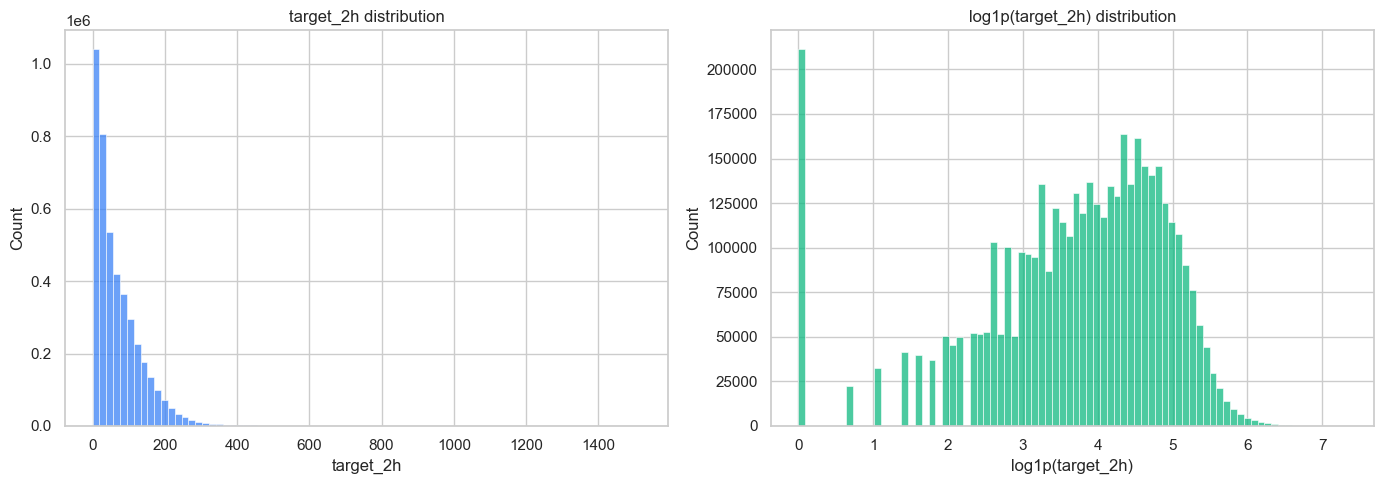

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train[TARGET_COL], bins=80, ax=axes[0], color="#3b82f6")
axes[0].set_title("target_2h distribution")
axes[0].set_xlabel("target_2h")

sns.histplot(np.log1p(train[TARGET_COL]), bins=80, ax=axes[1], color="#10b981")
axes[1].set_title("log1p(target_2h) distribution")
axes[1].set_xlabel("log1p(target_2h)")

plt.tight_layout()
plt.show()


,mean,std,min,max
status_7,2243.071239,4913.773645,0.0,76319.0
status_5,1555.774074,2194.728055,0.0,26565.0
status_6,1555.737880,2255.212710,0.0,27702.0
status_1,1310.748731,2501.866251,0.0,36491.0
status_3,1278.569003,2310.502482,0.0,26020.0
status_4,1102.996098,1740.374614,0.0,21170.0
status_8,916.167541,1872.031485,0.0,52039.0
status_2,146.998607,206.666088,0.0,17150.0


Correlation with target_2h:


status_5    0.481257
status_6    0.468166
status_4    0.426476
status_3    0.422644
status_1    0.389965
status_8    0.334934
status_7    0.332776
status_2    0.085748
Name: target_2h, dtype: float64

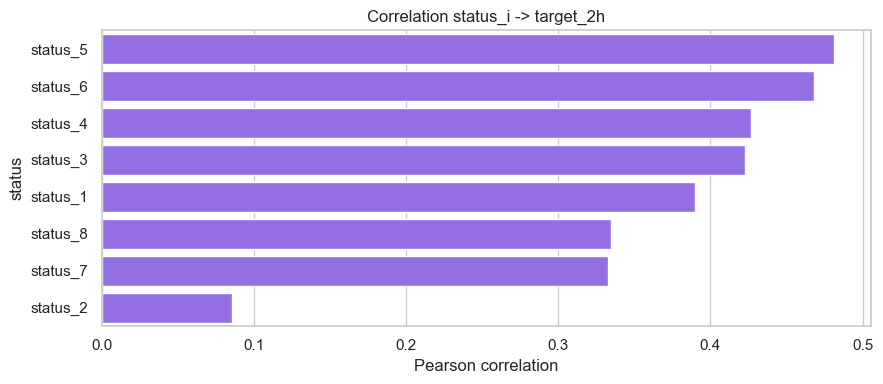

In [14]:

status_stats = train[STATUS_COLS].agg(["mean", "std", "min", "max"]).T.sort_values("mean", ascending=False)
display(status_stats)

corr_to_target = train[STATUS_COLS + [TARGET_COL]].corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
print("Correlation with target_2h:")
display(corr_to_target)

plt.figure(figsize=(9, 4))
sns.barplot(x=corr_to_target.values, y=corr_to_target.index, orient="h", color="#8b5cf6")
plt.title("Correlation status_i -> target_2h")
plt.xlabel("Pearson correlation")
plt.ylabel("status")
plt.tight_layout()
plt.show()


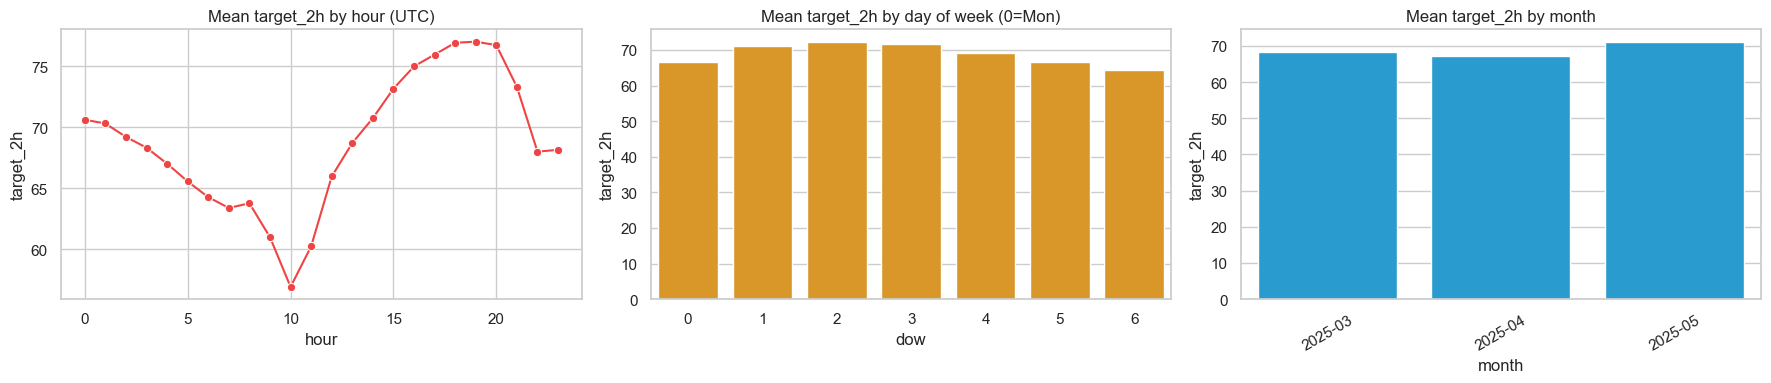

In [15]:

train_ts = train.copy()
train_ts["hour"] = train_ts["timestamp"].dt.hour
train_ts["dow"] = train_ts["timestamp"].dt.dayofweek
train_ts["month"] = train_ts["timestamp"].dt.to_period("M").astype(str)

hourly = train_ts.groupby("hour", as_index=False)[TARGET_COL].mean()
dow = train_ts.groupby("dow", as_index=False)[TARGET_COL].mean()
monthly = train_ts.groupby("month", as_index=False)[TARGET_COL].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.lineplot(data=hourly, x="hour", y=TARGET_COL, marker="o", ax=axes[0], color="#ef4444")
axes[0].set_title("Mean target_2h by hour (UTC)")

sns.barplot(data=dow, x="dow", y=TARGET_COL, ax=axes[1], color="#f59e0b")
axes[1].set_title("Mean target_2h by day of week (0=Mon)")

sns.barplot(data=monthly, x="month", y=TARGET_COL, ax=axes[2], color="#0ea5e9")
axes[2].set_title("Mean target_2h by month")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


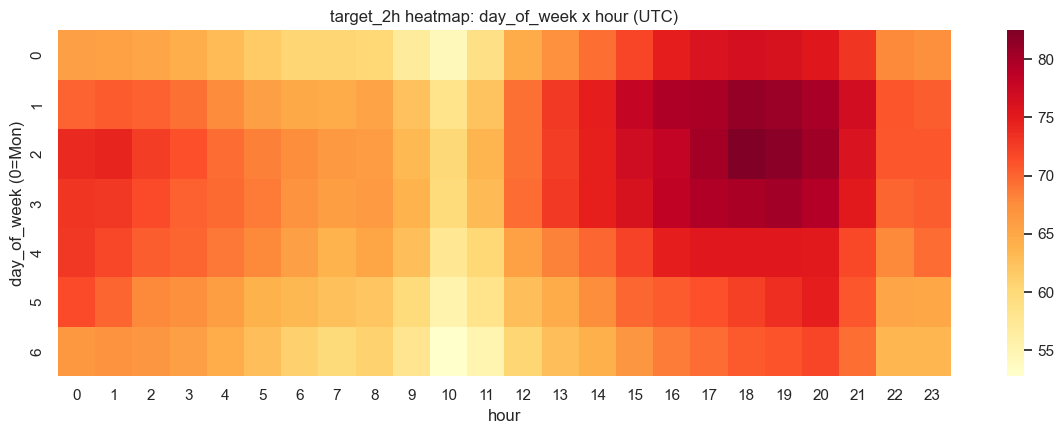

In [16]:

pivot_hour_dow = train_ts.pivot_table(
    values=TARGET_COL, index="dow", columns="hour", aggfunc="mean"
)

plt.figure(figsize=(12, 4.5))
sns.heatmap(pivot_hour_dow, cmap="YlOrRd")
plt.title("target_2h heatmap: day_of_week x hour (UTC)")
plt.xlabel("hour")
plt.ylabel("day_of_week (0=Mon)")
plt.tight_layout()
plt.show()


Train start: 2025-03-01 00:00:00+00:00
Train end: 2025-05-30 10:30:00+00:00
Test start: 2025-05-30 11:00:00+00:00
Test end: 2025-05-30 15:30:00+00:00
Gap test_min - train_max: 0 days 00:30:00


,hour,full,last14d
0,0,70.617099,70.748536
1,1,70.310984,70.524929
2,2,69.206385,69.785857
3,3,68.326989,70.073393
4,4,67.014324,68.871571
5,5,65.559044,67.276357
6,6,64.269560,66.701821
7,7,63.381643,66.307750
8,8,63.767797,67.243250
9,9,60.984918,65.926143


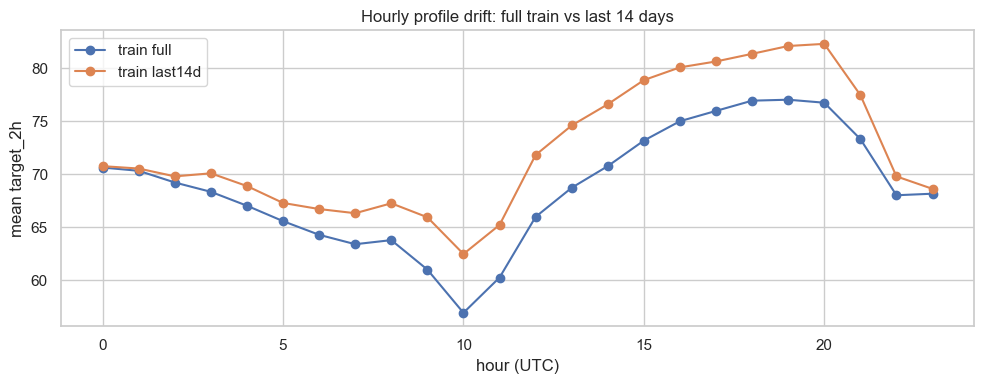

In [17]:

train_end = train["timestamp"].max()
train_start = train["timestamp"].min()

print("Train start:", train_start)
print("Train end:", train_end)
print("Test start:", test["timestamp"].min())
print("Test end:", test["timestamp"].max())
print("Gap test_min - train_max:", test["timestamp"].min() - train_end)

cut_14d = train_end - pd.Timedelta(days=14)
train_last14 = train_ts[train_ts["timestamp"] >= cut_14d].copy()

hourly_full = train_ts.groupby("hour", as_index=False)[TARGET_COL].mean().rename(columns={TARGET_COL: "full"})
hourly_last14 = train_last14.groupby("hour", as_index=False)[TARGET_COL].mean().rename(columns={TARGET_COL: "last14d"})

cmp_hour = hourly_full.merge(hourly_last14, on="hour", how="outer").sort_values("hour")
display(cmp_hour)

plt.figure(figsize=(10, 4))
plt.plot(cmp_hour["hour"], cmp_hour["full"], marker="o", label="train full")
plt.plot(cmp_hour["hour"], cmp_hour["last14d"], marker="o", label="train last14d")
plt.title("Hourly profile drift: full train vs last 14 days")
plt.xlabel("hour (UTC)")
plt.ylabel("mean target_2h")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:

test_points = pd.Series(sorted(test["timestamp"].unique()), name="test_ts")
history_days = (test_points - train_start).dt.total_seconds() / 86400

history_df = pd.DataFrame({
    "test_ts": test_points,
    "history_days_before_point": history_days.round(2)
})
display(history_df)

print("\nВывод:")
print("- для каждой точки теста есть ~90 дней истории train;")
print("- тест находится сразу после train (gap = 30 мин), поэтому нужен forward-only сценарий;")
print("- важны лаги и rolling-признаки по route_id, а также календарные признаки.")


,test_ts,history_days_before_point
0,2025-05-30 11:00:00+00:00,90.46
1,2025-05-30 11:30:00+00:00,90.48
2,2025-05-30 12:00:00+00:00,90.50
3,2025-05-30 12:30:00+00:00,90.52
4,2025-05-30 13:00:00+00:00,90.54
5,2025-05-30 13:30:00+00:00,90.56
6,2025-05-30 14:00:00+00:00,90.58
7,2025-05-30 14:30:00+00:00,90.60
8,2025-05-30 15:00:00+00:00,90.62
9,2025-05-30 15:30:00+00:00,90.65



Вывод:
- для каждой точки теста есть ~90 дней истории train;
- тест находится сразу после train (gap = 30 мин), поэтому нужен forward-only сценарий;
- важны лаги и rolling-признаки по route_id, а также календарные признаки.


In [19]:

def build_route_volume_groups(train_df, n_groups=3):
    route_stat = (
        train_df.groupby("route_id", as_index=False)[TARGET_COL]
        .mean()
        .rename(columns={TARGET_COL: "route_target_mean"})
    )

    route_stat["route_group"] = pd.qcut(
        route_stat["route_target_mean"],
        q=n_groups,
        labels=False,
        duplicates="drop"
    ).astype("int8")

    return route_stat

route_groups = build_route_volume_groups(train, n_groups=3)

train = train.merge(route_groups, on="route_id", how="left")
test = test.merge(route_groups, on="route_id", how="left")

train["route_group"] = train["route_group"].fillna(-1).astype("int8")
test["route_group"] = test["route_group"].fillna(-1).astype("int8")

route_group_map = dict(zip(route_groups["route_id"], route_groups["route_group"]))

print("Распределение route_group в train:")
print(train["route_group"].value_counts(dropna=False).sort_index())

print("\nСтатистика по группам:")
display(
    train.groupby("route_group")[TARGET_COL]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_index()
)


Распределение route_group в train:
route_group
0    1450228
1    1441544
2    1450228
Name: count, dtype: int64

Статистика по группам:


,count,mean,median,std,min,max
route_group,,,,,,
0,1450228,18.713297,16.0,18.801617,0.0,1053.0
1,1441544,55.059135,49.0,38.205900,0.0,1239.0
2,1450228,132.381154,121.0,71.367356,0.0,1517.0


In [20]:

group_name_map = {0: "low", 1: "mid", 2: "high", -1: "unknown"}

train["route_group_name"] = train["route_group"].map(group_name_map)
test["route_group_name"] = test["route_group"].map(group_name_map)

display(train[["route_id", "route_group", "route_group_name"]].drop_duplicates().head(10))


,route_id,route_group,route_group_name
0,29,1,mid
4342,65,1,mid
8684,191,2,high
13026,558,2,high
17368,222,0,low
21710,293,0,low
26052,730,2,high
30394,938,1,mid
34736,243,0,low
39078,442,2,high


In [21]:

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_true - y_pred).sum() / denom


def relative_bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_pred.sum() - y_true.sum()) / denom


def comp_metric(y_true, y_pred):
    return wape(y_true, y_pred) + relative_bias(y_true, y_pred)


In [27]:
def add_time_features(df):
    out = df.copy()
    out["hour"] = out["timestamp"].dt.hour.astype("int16")
    out["dow"] = out["timestamp"].dt.dayofweek.astype("int16")
    out["is_weekend"] = (out["dow"] >= 5).astype("int8")
    out["w_sr"] = out["dow"].between(1, 3).astype("int8")   # вт-ср-чт
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24).astype("float32")
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24).astype("float32")
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7).astype("float32")
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7).astype("float32")
    return out


def build_feature_table(df):
    out = add_time_features(df)

    if "route_group" in out.columns:
        out["route_group"] = out["route_group"].fillna(-1).astype("int8")

    return out

In [28]:

def _safe_mean(arr):
    return float(np.mean(arr)) if len(arr) > 0 else np.nan


def _safe_std(arr):
    return float(np.std(arr)) if len(arr) > 1 else 0.0


def make_row_features_from_history(route_id, ts, hist, route_group_map=None):
    row = {
        "route_id": route_id,
        "timestamp": ts,
    }

    if route_group_map is not None:
        row["route_group"] = int(route_group_map.get(route_id, -1))
    else:
        row["route_group"] = -1

    hour = ts.hour
    dow = ts.dayofweek

    row["hour"] = hour
    row["dow"] = dow
    row["is_weekend"] = int(dow >= 5)
    row["w_sr"] = int(1 <= dow <= 3)

    row["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    row["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    row["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    row["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    for lag in LAGS:
        row[f"y_lag_{lag}"] = hist[-lag] if len(hist) >= lag else np.nan

    for w in ROLL_WINDOWS:
        window = hist[-w:] if len(hist) >= 1 else []
        row[f"y_roll_mean_{w}"] = _safe_mean(window)
        row[f"y_roll_std_{w}"] = _safe_std(window)

    return row


In [30]:

train_fe = build_feature_table(train)
test_fe = build_feature_table(test)

print("train_fe shape:", train_fe.shape)
print("test_fe shape:", test_fe.shape)

display(train_fe.head())
display(test_fe.head())


train_fe shape: (4342000, 23)
test_fe shape: (10000, 14)


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,route_target_mean,route_group,route_group_name,hour,dow,is_weekend,w_sr,hour_sin,hour_cos,dow_sin,dow_cos
0,4,29,2025-03-01 00:00:00+00:00,3105,340,2160,484,4018,3462,0,0,27.0,72.055044,1,mid,0,5,1,0,0.000000,1.000000,-0.974928,-0.222521
1,4,29,2025-03-01 00:30:00+00:00,2813,388,2058,373,1363,1657,9380,0,27.0,72.055044,1,mid,0,5,1,0,0.000000,1.000000,-0.974928,-0.222521
2,4,29,2025-03-01 01:00:00+00:00,2465,293,2098,472,3195,3325,0,0,23.0,72.055044,1,mid,1,5,1,0,0.258819,0.965926,-0.974928,-0.222521
3,4,29,2025-03-01 01:30:00+00:00,1977,252,2351,310,3314,3243,0,0,37.0,72.055044,1,mid,1,5,1,0,0.258819,0.965926,-0.974928,-0.222521
4,4,29,2025-03-01 02:00:00+00:00,1585,206,2500,300,2130,1604,0,0,31.0,72.055044,1,mid,2,5,1,0,0.500000,0.866025,-0.974928,-0.222521


,id,route_id,timestamp,route_target_mean,route_group,route_group_name,hour,dow,is_weekend,w_sr,hour_sin,hour_cos,dow_sin,dow_cos
0,0,29,2025-05-30 11:00:00+00:00,72.055044,1,mid,11,4,0,0,2.588190e-01,-0.965926,-0.433884,-0.900969
1,1,29,2025-05-30 11:30:00+00:00,72.055044,1,mid,11,4,0,0,2.588190e-01,-0.965926,-0.433884,-0.900969
2,2,29,2025-05-30 12:00:00+00:00,72.055044,1,mid,12,4,0,0,1.224647e-16,-1.000000,-0.433884,-0.900969
3,3,29,2025-05-30 12:30:00+00:00,72.055044,1,mid,12,4,0,0,1.224647e-16,-1.000000,-0.433884,-0.900969
4,4,29,2025-05-30 13:00:00+00:00,72.055044,1,mid,13,4,0,0,-2.588190e-01,-0.965926,-0.433884,-0.900969


In [31]:
def make_rolling_time_splits(df, time_col="timestamp", n_splits=3, valid_days=7, min_train_days=30):
    data = df.sort_values(time_col).copy()
    ts_unique = pd.Series(sorted(data[time_col].unique()))

    max_ts = ts_unique.max()
    splits = []

    for i in range(n_splits, 0, -1):
        valid_end = max_ts - pd.Timedelta(days=valid_days * (i - 1))
        valid_start = valid_end - pd.Timedelta(days=valid_days)
        train_end = valid_start

        train_start = data[time_col].min()
        if (train_end - train_start).days < min_train_days:
            continue

        train_idx = data[time_col] < train_end
        valid_idx = (data[time_col] >= valid_start) & (data[time_col] < valid_end)

        if train_idx.sum() > 0 and valid_idx.sum() > 0:
            splits.append((train_idx, valid_idx, valid_start, valid_end))

    return splits

In [32]:
splits = make_rolling_time_splits(
    train_fe,
    time_col="timestamp",
    n_splits=3,
    valid_days=7,
    min_train_days=30
)

for i, (tr_idx, va_idx, va_start, va_end) in enumerate(splits, 1):
    print(f"Split {i}:")
    print("  valid:", va_start, "->", va_end)
    print("  train rows:", tr_idx.sum())
    print("  valid rows:", va_idx.sum())

Split 1:
  valid: 2025-05-09 10:30:00+00:00 -> 2025-05-16 10:30:00+00:00
  train rows: 3333000
  valid rows: 336000
Split 2:
  valid: 2025-05-16 10:30:00+00:00 -> 2025-05-23 10:30:00+00:00
  train rows: 3669000
  valid rows: 336000
Split 3:
  valid: 2025-05-23 10:30:00+00:00 -> 2025-05-30 10:30:00+00:00
  train rows: 4005000
  valid rows: 336000


In [33]:
def evaluate_model_time_split(
    model,
    df,
    feature_cols,
    target_col="target_2h",
    time_col="timestamp",
    valid_days=7
):
    train_part, valid_part, cutoff = time_split(df, time_col=time_col, valid_days=valid_days)

    X_train = train_part[feature_cols].copy()
    y_train = train_part[target_col].copy()

    X_valid = valid_part[feature_cols].copy()
    y_valid = valid_part[target_col].copy()

    # простая обработка пропусков
    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(X_train[col]):
            med = X_train[col].median()
            X_train[col] = X_train[col].fillna(med)
            X_valid[col] = X_valid[col].fillna(med)
        else:
            X_train[col] = X_train[col].fillna("missing")
            X_valid[col] = X_valid[col].fillna("missing")

    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    pred = np.clip(pred, 0, None)

    result = {
        "cutoff": cutoff,
        "train_rows": len(train_part),
        "valid_rows": len(valid_part),
        "wape": wape(y_valid, pred),
        "relative_bias": relative_bias(y_valid, pred),
        "comp_metric": comp_metric(y_valid, pred),
    }

    return result, pred, valid_part

# модели

In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [ ]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_true - y_pred).sum() / denom


def relative_bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_pred.sum() - y_true.sum()) / denom


def comp_metric(y_true, y_pred):
    return wape(y_true, y_pred) + relative_bias(y_true, y_pred)

In [ ]:
def time_split(df, time_col="timestamp", valid_days=7):
    data = df.sort_values(time_col).copy()
    cutoff = data[time_col].max() - pd.Timedelta(days=valid_days)

    train_part = data[data[time_col] < cutoff].copy()
    valid_part = data[data[time_col] >= cutoff].copy()

    return train_part, valid_part, cutoff

In [ ]:
def build_route_volume_groups(train_df, target_col="target_2h", n_groups=3):
    route_stat = (
        train_df.groupby("route_id", as_index=False)[target_col]
        .mean()
        .rename(columns={target_col: "route_target_mean"})
    )

    route_stat["route_group"] = pd.qcut(
        route_stat["route_target_mean"],
        q=n_groups,
        labels=False,
        duplicates="drop"
    ).astype("int8")

    return route_stat[["route_id", "route_group"]]

In [ ]:
def add_time_features(df):
    out = df.copy()
    out["hour"] = out["timestamp"].dt.hour.astype("int16")
    out["dow"] = out["timestamp"].dt.dayofweek.astype("int16")
    out["is_weekend"] = (out["dow"] >= 5).astype("int8")
    out["w_sr"] = out["dow"].between(1, 3).astype("int8")   # вт-ср-чт

    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24).astype("float32")
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24).astype("float32")
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7).astype("float32")
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7).astype("float32")
    return out


def build_feature_table(df):
    out = add_time_features(df)

    if "route_group" in out.columns:
        out["route_group"] = out["route_group"].fillna(-1).astype("int8")

    return out

In [ ]:
def prepare_train_valid_features(
    full_train_df,
    target_col="target_2h",
    time_col="timestamp",
    valid_days=7
):
    train_part, valid_part, cutoff = time_split(
        full_train_df,
        time_col=time_col,
        valid_days=valid_days
    )

    # строим route_group только на прошлом
    route_groups = build_route_volume_groups(
        train_part,
        target_col=target_col,
        n_groups=3
    )

    train_part = train_part.merge(route_groups, on="route_id", how="left")
    valid_part = valid_part.merge(route_groups, on="route_id", how="left")

    train_part["route_group"] = train_part["route_group"].fillna(-1).astype("int8")
    valid_part["route_group"] = valid_part["route_group"].fillna(-1).astype("int8")

    train_fe = build_feature_table(train_part)
    valid_fe = build_feature_table(valid_part)

    return train_fe, valid_fe, cutoff

In [ ]:
def prepare_train_test_features(
    train_df,
    test_df,
    target_col="target_2h"
):
    route_groups = build_route_volume_groups(
        train_df,
        target_col=target_col,
        n_groups=3
    )

    train_tmp = train_df.merge(route_groups, on="route_id", how="left")
    test_tmp = test_df.merge(route_groups, on="route_id", how="left")

    train_tmp["route_group"] = train_tmp["route_group"].fillna(-1).astype("int8")
    test_tmp["route_group"] = test_tmp["route_group"].fillna(-1).astype("int8")

    train_fe = build_feature_table(train_tmp)
    test_fe = build_feature_table(test_tmp)

    return train_fe, test_fe

In [ ]:
def get_feature_lists(df):
    status_cols = [c for c in df.columns if c.startswith("status_")]

    feature_cols = [
        "route_id",
        "office_from_id",
        "route_group",
        "hour",
        "dow",
        "is_weekend",
        "w_sr",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    ] + status_cols

    feature_cols = [c for c in feature_cols if c in df.columns]

    categorical_cols = [c for c in ["route_id", "office_from_id", "route_group"] if c in feature_cols]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    return feature_cols, categorical_cols, numeric_cols

In [ ]:
def encode_for_tree_models(train_df, valid_df, feature_cols, categorical_cols):
    X_train = train_df[feature_cols].copy()
    X_valid = valid_df[feature_cols].copy()

    encoders = {}

    for col in categorical_cols:
        train_vals = X_train[col].astype(str).fillna("missing")
        valid_vals = X_valid[col].astype(str).fillna("missing")

        all_vals = pd.Index(train_vals.unique()).union(pd.Index(valid_vals.unique()))
        mapping = {v: i for i, v in enumerate(all_vals)}

        X_train[col] = train_vals.map(mapping).astype("int32")
        X_valid[col] = valid_vals.map(mapping).astype("int32")
        encoders[col] = mapping

    for col in X_train.columns:
        if col not in categorical_cols:
            med = X_train[col].median()
            X_train[col] = X_train[col].fillna(med)
            X_valid[col] = X_valid[col].fillna(med)

    return X_train, X_valid, encoders

In [ ]:
def fit_predict_model(
    model_name,
    train_fe,
    valid_fe,
    target_col="target_2h"
):
    feature_cols, categorical_cols, numeric_cols = get_feature_lists(train_fe)

    y_train = train_fe[target_col].values
    y_valid = valid_fe[target_col].values

    y_train_log = np.log1p(y_train)

    if model_name == "catboost":
        X_train = train_fe[feature_cols].copy()
        X_valid = valid_fe[feature_cols].copy()

        for col in categorical_cols:
            X_train[col] = X_train[col].astype(str)
            X_valid[col] = X_valid[col].astype(str)

        for col in numeric_cols:
            med = X_train[col].median()
            X_train[col] = X_train[col].fillna(med)
            X_valid[col] = X_valid[col].fillna(med)

        cat_features_idx = [X_train.columns.get_loc(c) for c in categorical_cols]

        model = CatBoostRegressor(
            iterations=700,
            depth=8,
            learning_rate=0.05,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_state=42,
            verbose=0
        )

        model.fit(
            X_train,
            y_train_log,
            cat_features=cat_features_idx
        )

        pred_log = model.predict(X_valid)

    elif model_name == "hgb":
        X_train, X_valid, _ = encode_for_tree_models(
            train_fe, valid_fe, feature_cols, categorical_cols
        )

        model = HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=400,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=42
        )

        model.fit(X_train, y_train_log)
        pred_log = model.predict(X_valid)

    elif model_name == "rf":
        X_train, X_valid, _ = encode_for_tree_models(
            train_fe, valid_fe, feature_cols, categorical_cols
        )

        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=14,
            min_samples_leaf=8,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train, y_train_log)
        pred_log = model.predict(X_valid)

    elif model_name == "lightgbm":
        X_train, X_valid, _ = encode_for_tree_models(
            train_fe, valid_fe, feature_cols, categorical_cols
        )

        model = LGBMRegressor(
            n_estimators=700,
            learning_rate=0.05,
            max_depth=8,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, y_train_log)
        pred_log = model.predict(X_valid)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    result = {
        "model": model_name,
        "wape": wape(y_valid, pred),
        "relative_bias": relative_bias(y_valid, pred),
        "comp_metric": comp_metric(y_valid, pred),
    }

    return result, pred, model

In [ ]:
def build_validation_leaderboard(
    full_train_df,
    target_col="target_2h",
    time_col="timestamp",
    valid_days=7
):
    train_fe, valid_fe, cutoff = prepare_train_valid_features(
        full_train_df,
        target_col=target_col,
        time_col=time_col,
        valid_days=valid_days
    )

    results = []
    oof_preds = {}
    fitted_models = {}

    for model_name in ["hgb", "catboost", "rf", "lightgbm"]:
        print(f"Training: {model_name}")
        res, pred, model = fit_predict_model(
            model_name=model_name,
            train_fe=train_fe,
            valid_fe=valid_fe,
            target_col=target_col
        )
        res["cutoff"] = cutoff
        results.append(res)
        oof_preds[model_name] = pred
        fitted_models[model_name] = model

    leaderboard = pd.DataFrame(results).sort_values("comp_metric", ascending=True).reset_index(drop=True)
    return leaderboard, train_fe, valid_fe, oof_preds, fitted_models

In [ ]:
leaderboard, train_fe_val, valid_fe_val, valid_preds, fitted_models = build_validation_leaderboard(
    train,
    target_col="target_2h",
    time_col="timestamp",
    valid_days=7
)

display(leaderboard)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(data=leaderboard, x="comp_metric", y="model")
plt.title("Validation leaderboard (lower is better)")
plt.xlabel("comp_metric = WAPE + |Relative Bias|")
plt.ylabel("model")
plt.tight_layout()
plt.show()

In [ ]:
import os
import json
import joblib
from pathlib import Path

In [ ]:
MODELS_DIR = Path("saved_models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Models dir:", MODELS_DIR.resolve())

In [ ]:
def save_trained_model(model, model_name, feature_cols, categorical_cols, models_dir=MODELS_DIR):
    models_dir = Path(models_dir)
    models_dir.mkdir(parents=True, exist_ok=True)

    metadata = {
        "model_name": model_name,
        "feature_cols": feature_cols,
        "categorical_cols": categorical_cols,
    }

    if model_name == "catboost":
        model_path = models_dir / f"{model_name}.cbm"
        model.save_model(str(model_path))
    else:
        model_path = models_dir / f"{model_name}.joblib"
        joblib.dump(model, model_path)

    meta_path = models_dir / f"{model_name}_meta.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    return model_path, meta_path

In [ ]:
from catboost import CatBoostRegressor

def load_trained_model(model_name, models_dir=MODELS_DIR):
    models_dir = Path(models_dir)

    meta_path = models_dir / f"{model_name}_meta.json"
    with open(meta_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    if model_name == "catboost":
        model_path = models_dir / f"{model_name}.cbm"
        model = CatBoostRegressor()
        model.load_model(str(model_path))
    else:
        model_path = models_dir / f"{model_name}.joblib"
        model = joblib.load(model_path)

    return model, metadata

In [ ]:
def fit_full_and_predict_test(
    model_name,
    train_df,
    test_df,
    target_col="target_2h",
    models_dir=MODELS_DIR,
    save_model_flag=True
):
    train_fe, test_fe = prepare_train_test_features(
        train_df=train_df,
        test_df=test_df,
        target_col=target_col
    )

    feature_cols, categorical_cols, numeric_cols = get_feature_lists(train_fe)

    y_train = train_fe[target_col].values
    y_train_log = np.log1p(y_train)

    if model_name == "catboost":
        X_train = train_fe[feature_cols].copy()
        X_test = test_fe[feature_cols].copy()

        for col in categorical_cols:
            X_train[col] = X_train[col].astype(str)
            X_test[col] = X_test[col].astype(str)

        for col in numeric_cols:
            med = X_train[col].median()
            X_train[col] = X_train[col].fillna(med)
            X_test[col] = X_test[col].fillna(med)

        cat_features_idx = [X_train.columns.get_loc(c) for c in categorical_cols]

        model = CatBoostRegressor(
            iterations=700,
            depth=8,
            learning_rate=0.05,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_state=42,
            verbose=0
        )

        model.fit(
            X_train,
            y_train_log,
            cat_features=cat_features_idx
        )

        pred_log = model.predict(X_test)

    elif model_name == "hgb":
        X_train, X_test, _ = encode_for_tree_models(
            train_fe, test_fe, feature_cols, categorical_cols
        )

        model = HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=400,
            min_samples_leaf=30,
            l2_regularization=1.0,
            random_state=42
        )

        model.fit(X_train, y_train_log)
        pred_log = model.predict(X_test)

    elif model_name == "rf":
        X_train, X_test, _ = encode_for_tree_models(
            train_fe, test_fe, feature_cols, categorical_cols
        )

        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=14,
            min_samples_leaf=8,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train, y_train_log)
        pred_log = model.predict(X_test)

    elif model_name == "lightgbm":
        X_train, X_test, _ = encode_for_tree_models(
            train_fe, test_fe, feature_cols, categorical_cols
        )

        model = LGBMRegressor(
            n_estimators=700,
            learning_rate=0.05,
            max_depth=8,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, y_train_log)
        pred_log = model.predict(X_test)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    submission = pd.DataFrame({
        "id": test_df["id"].values,
        "y_pred": pred
    })

    model_path, meta_path = None, None
    if save_model_flag:
        model_path, meta_path = save_trained_model(
            model=model,
            model_name=model_name,
            feature_cols=feature_cols,
            categorical_cols=categorical_cols,
            models_dir=models_dir
        )

    return submission, model, model_path, meta_path

In [ ]:
all_submissions = {}
saved_model_paths = {}

for model_name in ["hgb", "catboost", "rf", "lightgbm"]:
    print(f"Fitting full train for {model_name}")

    subm, model, model_path, meta_path = fit_full_and_predict_test(
        model_name=model_name,
        train_df=train,
        test_df=test,
        target_col="target_2h",
        models_dir=MODELS_DIR,
        save_model_flag=True
    )

    all_submissions[model_name] = subm
    saved_model_paths[model_name] = {
        "model_path": str(model_path) if model_path is not None else None,
        "meta_path": str(meta_path) if meta_path is not None else None,
    }

    subm.to_csv(f"submission_{model_name}.csv", index=False)
    print(f"Saved submission_{model_name}.csv")
    print(f"Saved model: {model_path}")
    print(f"Saved meta : {meta_path}")
    print("-" * 60)

пример ансамбля 

In [ ]:
def predict_with_saved_model(
    model_name,
    train_df,
    test_df,
    target_col="target_2h",
    models_dir=MODELS_DIR
):
    model, metadata = load_trained_model(model_name, models_dir=models_dir)

    train_fe, test_fe = prepare_train_test_features(
        train_df=train_df,
        test_df=test_df,
        target_col=target_col
    )

    feature_cols = metadata["feature_cols"]
    categorical_cols = metadata["categorical_cols"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    if model_name == "catboost":
        X_test = test_fe[feature_cols].copy()

        for col in categorical_cols:
            X_test[col] = X_test[col].astype(str)

        for col in numeric_cols:
            med = train_fe[col].median()
            X_test[col] = X_test[col].fillna(med)

        pred_log = model.predict(X_test)

    else:
        X_train_ref = train_fe[feature_cols].copy()
        X_test = test_fe[feature_cols].copy()

        # кодируем категории одинаково через train_fe
        for col in categorical_cols:
            train_vals = X_train_ref[col].astype(str).fillna("missing")
            test_vals = X_test[col].astype(str).fillna("missing")

            all_vals = pd.Index(train_vals.unique()).union(pd.Index(test_vals.unique()))
            mapping = {v: i for i, v in enumerate(all_vals)}

            X_train_ref[col] = train_vals.map(mapping).astype("int32")
            X_test[col] = test_vals.map(mapping).astype("int32")

        for col in X_test.columns:
            if col not in categorical_cols:
                med = X_train_ref[col].median()
                X_test[col] = X_test[col].fillna(med)

        pred_log = model.predict(X_test)

    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    return pred

In [ ]:
ensemble_models = ["catboost", "lightgbm", "hgb"]

ensemble_preds = []
for model_name in ensemble_models:
    pred = predict_with_saved_model(
        model_name=model_name,
        train_df=train,
        test_df=test,
        target_col="target_2h",
        models_dir=MODELS_DIR
    )
    ensemble_preds.append(pred)

ensemble_pred = np.mean(ensemble_preds, axis=0)

submission_ensemble = pd.DataFrame({
    "id": test["id"].values,
    "y_pred": ensemble_pred
})

submission_ensemble.to_csv("submission_ensemble_mean.csv", index=False)
print("Saved: submission_ensemble_mean.csv")